In [9]:
import numpy as np
import matplotlib.pyplot as plt

# sklearn imports
from sklearn.datasets import load_digits
from sklearn.model_selection import learning_curve
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.svm import SVC
from sklearn.model_selection import ShuffleSplit
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures

# from utils.visualization import BLUE, GREEN, standard_setup
# standard_setup()
BLUE = "steelblue"
GREEN = "darkgreen"

### 1. Learning curves

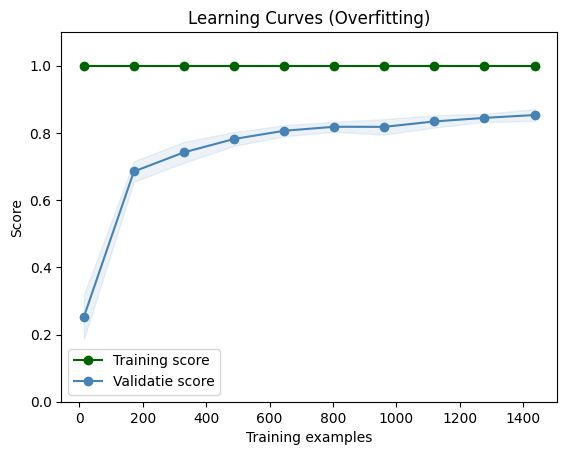

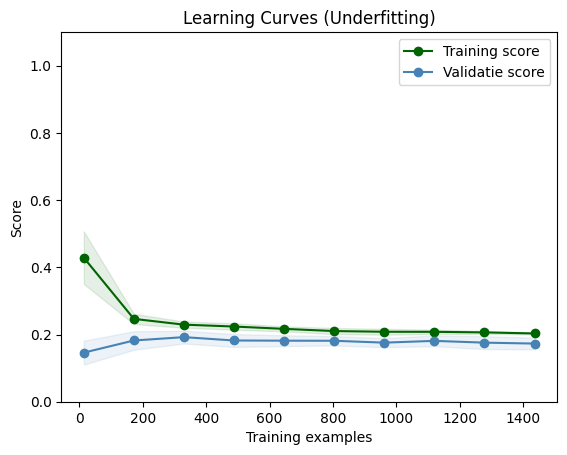

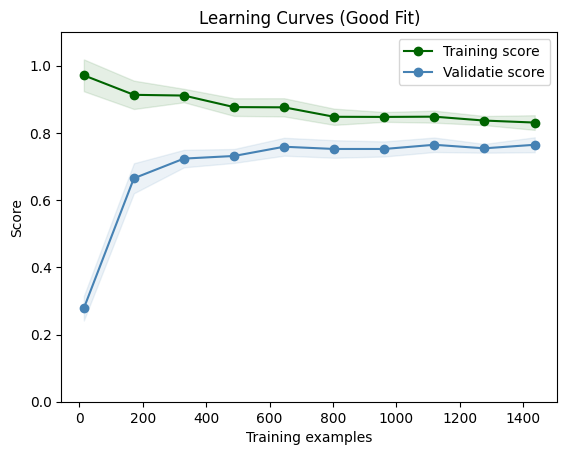

In [10]:
# Load the digits dataset
digits = load_digits()
X, y = digits.data, digits.target

# Define a function to plot learning curves
def plot_learning_curve(estimator, title, X, y, ax, ylim=None, cv=None, n_jobs=None, train_sizes=np.linspace(.01, 1.0, 10)):
    ax.set_title(title)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.set_xlabel("Training examples")
    ax.set_ylabel("Score")
    train_sizes, train_scores, test_scores = learning_curve(estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    ax.fill_between(train_sizes, train_scores_mean - train_scores_std,
                    train_scores_mean + train_scores_std, alpha=0.1,
                    color=GREEN)
    ax.fill_between(train_sizes, test_scores_mean - test_scores_std,
                    test_scores_mean + test_scores_std, alpha=0.1, color=BLUE)
    ax.plot(train_sizes, train_scores_mean, 'o-', color=GREEN,
            label="Training score")
    ax.plot(train_sizes, test_scores_mean, 'o-', color=BLUE,
            label="Validatie score")

    ax.legend(loc="best")
    return
    
# Define cross-validation strategy
cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=0)

# Plot learning curves for different scenarios
# Overfitting:
fig, ax = plt.subplots()
plot_learning_curve(DecisionTreeClassifier(max_depth=1000), "Learning Curves (Overfitting)", X, y, ax=ax, cv=cv, n_jobs=4, ylim = [0, 1.1])

# Underfitting
fig, ax = plt.subplots()
plot_learning_curve(DecisionTreeClassifier(max_depth=1), "Learning Curves (Underfitting)", X, y, ax=ax, cv=cv, n_jobs=4, ylim = [0, 1.1])

# Good fit
fig, ax = plt.subplots()
plot_learning_curve(DecisionTreeClassifier(max_depth=6), "Learning Curves (Good Fit)", X, y, ax=ax, cv=cv, n_jobs=4, ylim = [0, 1.1])

## 2.1 Ridge regressie

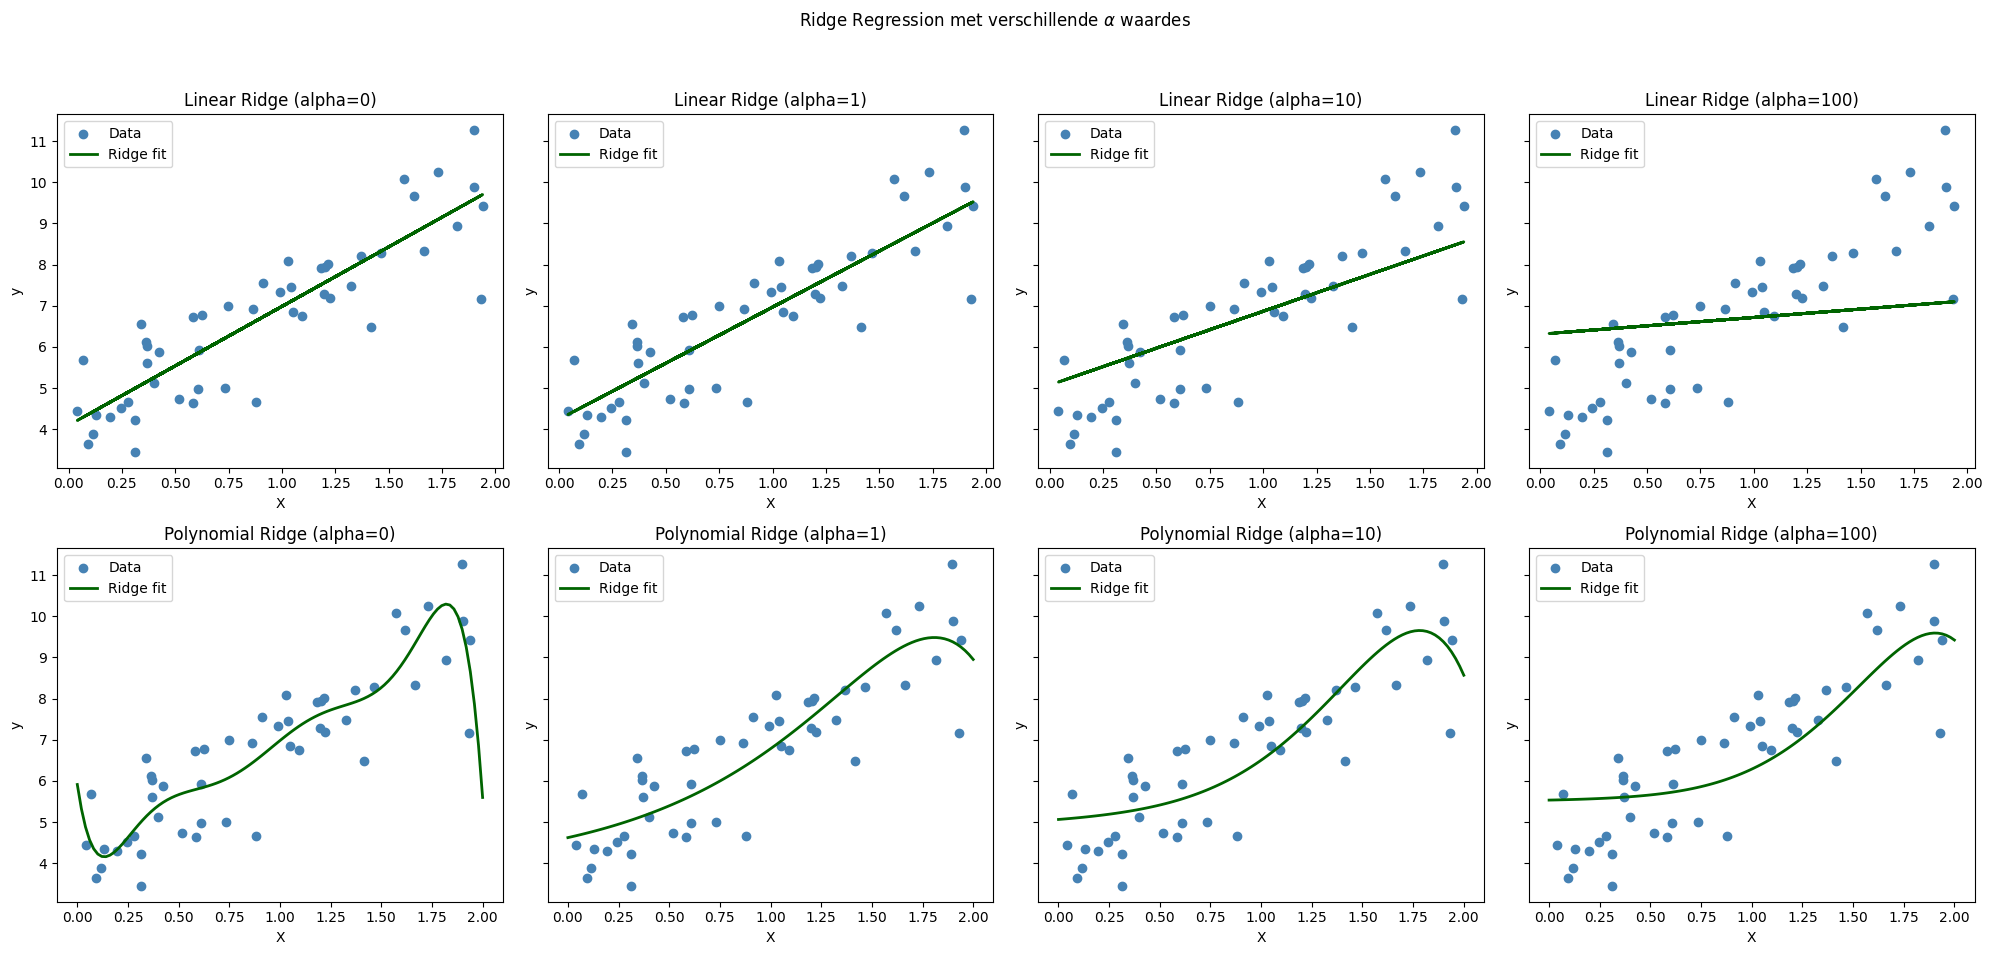

In [11]:
# Customizable parameters
data_size = 50
noise_variability = 1.0

# Create a synthetic dataset
np.random.seed(42)
X = 2 * np.random.rand(data_size, 1)
y = 4 + 3 * X + noise_variability * np.random.randn(data_size, 1)

# Define a range of alpha values
alphas = [0, 1, 10, 100]

# Plot settings
fig, axes = plt.subplots(2, len(alphas), figsize=(20, 10), sharey=True)
fig.suptitle(r"Ridge Regression met verschillende $\alpha$ waardes")

for i, alpha in enumerate(alphas):
    # Model 1: Linear regression with Ridge
    ridge_reg = Ridge(alpha=alpha)
    ridge_reg.fit(X, y)
    y_pred = ridge_reg.predict(X)
    
    axes[0, i].scatter(X, y, color=BLUE, marker='o', label='Data')
    axes[0, i].plot(X, y_pred, color=GREEN, linewidth=2, label='Ridge fit')
    axes[0, i].set_title(f'Linear Ridge (alpha={alpha})')
    axes[0, i].set_xlabel('X')
    axes[0, i].set_ylabel('y')
    axes[0, i].legend()
    
    # Model 2: Polynomial regression of degree 10 with Ridge
    polynomial_features = PolynomialFeatures(degree=7)
    X_poly = polynomial_features.fit_transform(X)
    ridge_poly_reg = Ridge(alpha=alpha)
    ridge_poly_reg.fit(X_poly, y)
    y_poly_pred = ridge_poly_reg.predict(X_poly)
    
    X_plot = np.linspace(0, 2, 100).reshape(-1, 1)
    X_poly_plot = polynomial_features.transform(X_plot)
    y_poly_plot = ridge_poly_reg.predict(X_poly_plot)
    
    axes[1, i].scatter(X, y, color=BLUE, marker='o', label='Data')
    axes[1, i].plot(X_plot, y_poly_plot, color=GREEN, linewidth=2, label='Ridge fit')
    axes[1, i].set_title(f'Polynomial Ridge (alpha={alpha})')
    axes[1, i].set_xlabel('X')
    axes[1, i].set_ylabel('y')
    axes[1, i].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

## 2.2 Lasso Regressie

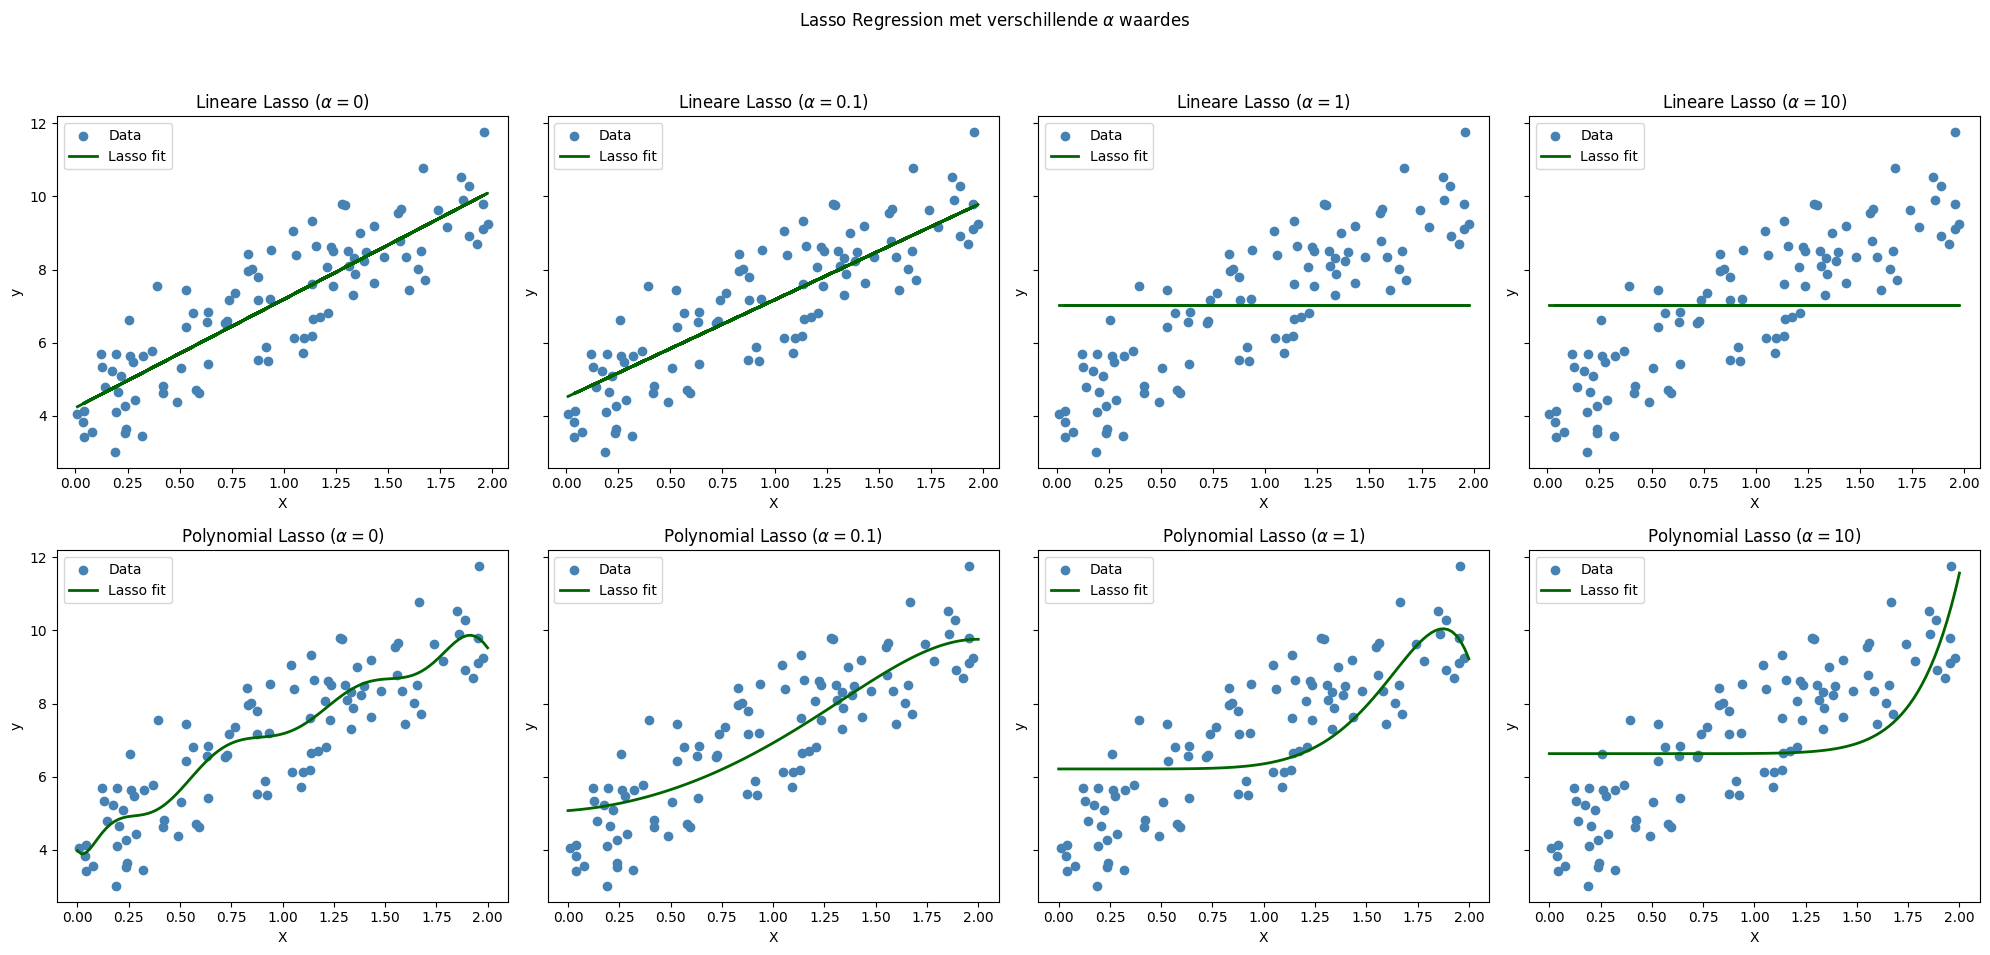

In [12]:
# Customizable parameters
data_size = 100
noise_variability = 1.0
polynomial_degree = 10

# Create a synthetic dataset
np.random.seed(0)
X = 2 * np.random.rand(data_size, 1)
y = 4 + 3 * X + noise_variability * np.random.randn(data_size, 1)

# Define a range of alpha values
alphas = [0, 0.1, 1, 10]

# Plot settings
fig, axes = plt.subplots(2, len(alphas), figsize=(20, 10), sharey=True)
fig.suptitle(r"Lasso Regression met verschillende $\alpha$ waardes")

for i, alpha in enumerate(alphas):
    # Model 1: Linear regression with Lasso
    if alpha == 0:
        lasso_reg = LinearRegression()
    else:
        lasso_reg = Lasso(alpha=alpha, max_iter=10000)
    lasso_reg.fit(X, y)
    y_pred = lasso_reg.predict(X)
    
    axes[0, i].scatter(X, y, color=BLUE, marker='o', label='Data')
    axes[0, i].plot(X, y_pred, color=GREEN, linewidth=2, label='Lasso fit')
    axes[0, i].set_title(rf'Lineare Lasso ($\alpha={alpha}$)')
    axes[0, i].set_xlabel('X')
    axes[0, i].set_ylabel('y')
    axes[0, i].legend()
    
    # Model 2: Polynomial regression with Lasso
    polynomial_features = PolynomialFeatures(degree=polynomial_degree)
    X_poly = polynomial_features.fit_transform(X)
    if alpha == 0:
        lasso_poly_reg = LinearRegression()
    else:
        lasso_poly_reg = Lasso(alpha=alpha, max_iter=10000)
    lasso_poly_reg.fit(X_poly, y)
    y_poly_pred = lasso_poly_reg.predict(X_poly)
    
    X_plot = np.linspace(0, 2, 100).reshape(-1, 1)
    X_poly_plot = polynomial_features.transform(X_plot)
    y_poly_plot = lasso_poly_reg.predict(X_poly_plot)
    
    axes[1, i].scatter(X, y, color=BLUE, marker='o', label='Data')
    axes[1, i].plot(X_plot, y_poly_plot, color=GREEN, linewidth=2, label='Lasso fit')
    axes[1, i].set_title(rf'Polynomial Lasso ($\alpha={alpha}$)')
    axes[1, i].set_xlabel('X')
    axes[1, i].set_ylabel('y')
    axes[1, i].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

### 3. Parameters van optimale oplossingen voor Lasso/Ridge gevisualizeerd.

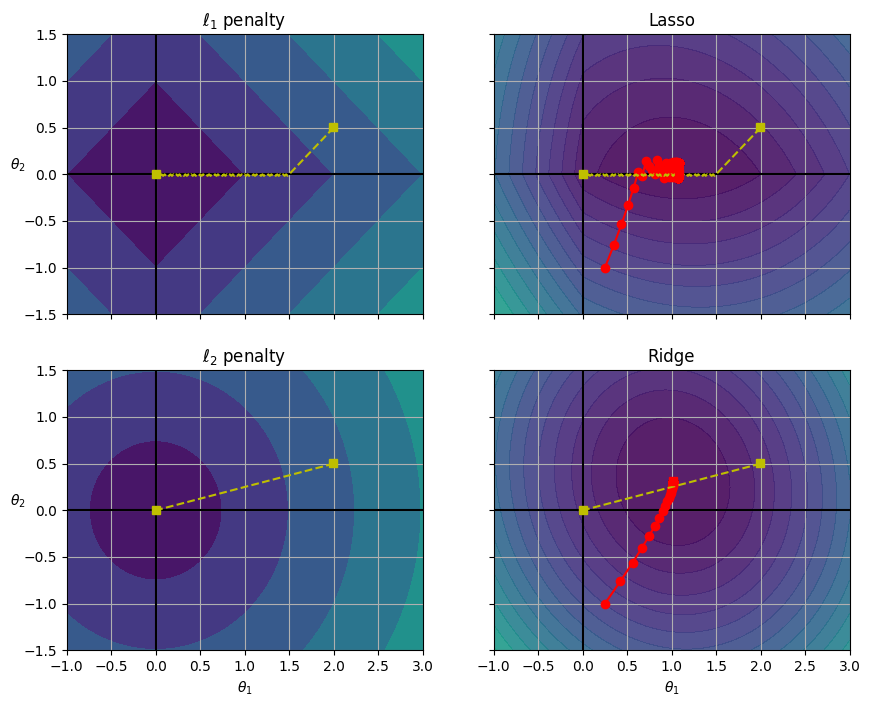

In [13]:
t1a, t1b, t2a, t2b = -1, 3, -1.5, 1.5

t1s = np.linspace(t1a, t1b, 500)
t2s = np.linspace(t2a, t2b, 500)
t1, t2 = np.meshgrid(t1s, t2s)
T = np.c_[t1.ravel(), t2.ravel()]
Xr = np.array([[1, 1], [1, -1], [1, 0.5]])
yr = 2 * Xr[:, :1] + 0.5 * Xr[:, 1:]

J = (1 / len(Xr) * ((T @ Xr.T - yr.T) ** 2).sum(axis=1)).reshape(t1.shape)

N1 = np.linalg.norm(T, ord=1, axis=1).reshape(t1.shape)
N2 = np.linalg.norm(T, ord=2, axis=1).reshape(t1.shape)

t_min_idx = np.unravel_index(J.argmin(), J.shape)
t1_min, t2_min = t1[t_min_idx], t2[t_min_idx]

t_init = np.array([[0.25], [-1]])

def bgd_path(theta, X, y, l1, l2, core=1, eta=0.05, n_iterations=200):
    path = [theta]
    for iteration in range(n_iterations):
        gradients = (core * 2 / len(X) * X.T @ (X @ theta - y)
                     + l1 * np.sign(theta) + l2 * theta)
        theta = theta - eta * gradients
        path.append(theta)
    return np.array(path)

fig, axes = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(10.1, 8))

for i, N, l1, l2, title in ((0, N1, 2.0, 0, "Lasso"), (1, N2, 0, 2.0, "Ridge")):
    JR = J + l1 * N1 + l2 * 0.5 * N2 ** 2

    tr_min_idx = np.unravel_index(JR.argmin(), JR.shape)
    t1r_min, t2r_min = t1[tr_min_idx], t2[tr_min_idx]

    levels = np.exp(np.linspace(0, 1, 20)) - 1
    levelsJ = levels * (J.max() - J.min()) + J.min()
    levelsJR = levels * (JR.max() - JR.min()) + JR.min()
    levelsN = np.linspace(0, N.max(), 10)

    path_J = bgd_path(t_init, Xr, yr, l1=0, l2=0)
    path_JR = bgd_path(t_init, Xr, yr, l1, l2)
    path_N = bgd_path(theta=np.array([[2.0], [0.5]]), X=Xr, y=yr,
                      l1=np.sign(l1) / 3, l2=np.sign(l2), core=0)
    ax = axes[i, 0]
    ax.grid()
    ax.axhline(y=0, color="k")
    ax.axvline(x=0, color="k")
    ax.contourf(t1, t2, N / 2.0, levels=levelsN)
    ax.plot(path_N[:, 0], path_N[:, 1], "y--")
    ax.plot(0, 0, "ys")
    ax.plot(t1_min, t2_min, "ys")
    ax.set_title(fr"$\ell_{i + 1}$ penalty")
    ax.axis([t1a, t1b, t2a, t2b])
    if i == 1:
        ax.set_xlabel(r"$\theta_1$")
    ax.set_ylabel(r"$\theta_2$", rotation=0)

    ax = axes[i, 1]
    ax.grid()
    ax.axhline(y=0, color="k")
    ax.axvline(x=0, color="k")
    ax.contourf(t1, t2, JR, levels=levelsJR, alpha=0.9)
    ax.plot(path_JR[:, 0], path_JR[:, 1], "r-o")
    ax.plot(path_N[:, 0], path_N[:, 1], "y--")
    ax.plot(0, 0, "ys")
    ax.plot(t1_min, t2_min, "ys")
    ax.plot(t1r_min, t2r_min, "rs")
    ax.set_title(title)
    ax.axis([t1a, t1b, t2a, t2b])
    if i == 1:
        ax.set_xlabel(r"$\theta_1$")